# Recherche tabu

In [226]:
import numpy as np
from scipy.spatial import distance_matrix

from collections import deque
import random
from functools import lru_cache

from functions import get_vrptw_instance
from functions import show 


## Variables

In [227]:
# Instances
instance_name = 'C101.txt'
data_set, data_set_solution = get_vrptw_instance(instance_name)

# DataSET
capacity = data_set['capacity']
coords = data_set['node_coord']
demand = data_set['demand']
nb_client=len(coords)-1

# dataSetSolution
best_solution = data_set_solution['routes']

## Mathematics things

In [228]:
# Distance between two points
points = np.array(coords)

DISTANCE = distance_matrix(points, points)

## Giant tour manipulation

In [229]:
def merge(solution):
    """
    Merge a solution into a giant list
    Args:
        solution(list[list[int]]):
            A solution of the vrp.
            With k lists of c int elements.
            With k number of routes(trucks) and c number of client in the route.
    Returns:
        giant_tour(list[int]): Merge of the all routes into a giant list.
    """
    giant_tour = []
    for route in solution:
        for city in route:
            if city != 0:
                giant_tour.append(city)
    return giant_tour

In [230]:
def split(giant_tour):
    """
    Split the giant tour into multiple feasible routes.
    Args:
        giant_tour (list[int]): A giant tour representing a full permutation
        of all clients.

    Returns:
        sol (list[list[int]]): A list of routes, where each route is a list
        of clients assigned to the same truck, respecting capacity constraints.
    """
    route=[]
    sol =[]
    cost =0 
    for client in giant_tour:
        if cost + demand[client] <= capacity:
            route.append(client)
            cost += demand[client]
        else :
            sol.append(route)
            cost = demand[client]
            route = [client] 
    sol.append(route)

    return sol 

## random solution

In [231]:
import matplotlib.pyplot as plt

def random_solution():
    """
    Generate a random VRP solution.
    Args:
        None

    Returns:
        solution (list[list[int]]): A feasible solution composed of several routes,
        obtained by generating a random giant tour and splitting it into routes
        respecting the truck capacity constraints.
    """

    giant_tour = random.sample(range(nb_client + 1), k=nb_client + 1)
    solution = split(giant_tour)
    return solution


# Neighborhood

In [232]:
def neighborhood(solution, nb_neighbors, nb_swaps_per_neighbor):
    """
    Find nb_neighbors solution's neighbor
    Args:
        solution(list[list[int]]):
            A solution of the vrp.
            With k lists of c int elements.
            With k number of routes(trucks) and c number of client in the route.
        nb_neighbors(int):
            number of neighbors that we want to have for the solution
        nb_swaps_per_neighbor(int):
            number of swap per neighbor.
            if nb_swaps_per_neighbor = 1 we swap 2 values between them
            if nb_swaps_per_neighbor = 2 we swap two time 2 differente values between them
    Returns:
        neighbors(list[solution]):
            list of nb_neighbors solution's neighbor
    """
    neighbors = []

    giant_tour = merge(solution)
    size_giant_tour = len(giant_tour)

    i, j = random.sample(range(size_giant_tour), 2)
    for _ in range(nb_neighbors):
        neighbor_giant_tour = giant_tour.copy()
        for _ in range(nb_swaps_per_neighbor):
            i, j = random.sample(range(size_giant_tour), 2)
            neighbor_giant_tour[i], neighbor_giant_tour[j] = neighbor_giant_tour[j], neighbor_giant_tour[i]
        neighbors.append(split(neighbor_giant_tour))
    return neighbors

# Weight evaluation

In [233]:

def total_travel_distance(solution):
    dist_tot = 0
    for route in solution:
        full_route = [0] + route + [0]
        for client in range(len(full_route)-1):
            origin = full_route[client]
            destination = full_route[client + 1]
            dist_tot += DISTANCE[origin, destination]

    return dist_tot



# TABOU RESEARCH 

In [234]:
iter_max = 200
tabu_size = nb_client *2 
nb_neighbors = 100
nb_swaps_per_neighbor = 1
n_iter =10

In [235]:

def tabu_search(initial_solution, tabu_size, iter_max, nb_neighbors, nb_swaps_per_neighbor):
    """
    1. We start from an element of our search set that we state current element
    2. We consider the neighbourhood of the current element, we choose the best of them
    as a new current element, among those missing from the tabu list, and we add it
    to the tabu list
    3. We run a loop until the output condition is reached.
    """
    nb_iter = 0
    tabu_list = deque(maxlen=tabu_size)

    # variables solutions for finding the neighbour optimal not tabu
    current_solution = initial_solution
    best = initial_solution
    best_global = initial_solution

    # variables values for finding neighbour optimal not tabu
    value_best = total_travel_distance(initial_solution)
    value_best_global = value_best


    while (nb_iter < iter_max):
        value_best = float('inf')
        # we go through all the neighbours of the current solution
        for neighbor in neighborhood(current_solution,nb_neighbors,nb_swaps_per_neighbor):
            neighbor_tuple =[ route for route in neighbor]
            if total_travel_distance(neighbor_tuple) < value_best and neighbor_tuple not in tabu_list:
                value_best = total_travel_distance(neighbor_tuple)
                best = neighbor_tuple

        # we update the best solution encountered since the beginning
        if value_best < value_best_global:
            best_global = best
            value_best_global = value_best
            nb_iter = 0
        else:
            nb_iter += 1

        # we go to the best non-tabu neighbour found
        current_solution = best

        # we update the tabu list
        tabu_list.append(current_solution)

    # ensure the returned solution has the original expected type: list of lists
    return best_global


In [236]:
# multi-start of n iterations
def multi_start(solution, tabu_size,iter_max, nb_neighbors,nb_swaps_per_neighbor, n_iter ):

    sol_max = None
    val_max = float("inf")
    for _ in range (n_iter):
        solution = random_solution()
        sol_courante = tabu_search(solution, tabu_size,iter_max, nb_neighbors,nb_swaps_per_neighbor )
        val_courante = total_travel_distance(sol_courante)
        if (val_courante < val_max):
            val_max = val_courante
            sol_max = sol_courante
    return val_max, sol_max

[[5, 3, 7, 8, 10, 11, 9, 6, 4, 2, 1, 75], [13, 17, 18, 19, 15, 16, 14, 12], [20, 24, 25, 27, 29, 30, 28, 26, 23, 22, 21], [32, 33, 31, 35, 37, 38, 39, 36, 34], [43, 42, 41, 40, 44, 46, 45, 48, 51, 50, 52, 49, 47], [57, 55, 54, 53, 56, 58, 60, 59], [67, 65, 63, 62, 74, 72, 61, 64, 68, 66, 69], [81, 78, 76, 71, 70, 73, 77, 79, 80], [90, 87, 86, 83, 82, 84, 85, 88, 89, 91], [98, 96, 95, 94, 92, 93, 97, 100, 99]]
828.9368669428343
[[88, 63, 91, 75, 98, 87, 24, 3, 30], [81, 0, 9, 99, 64, 36, 56, 22, 65, 57, 8], [97, 31, 38, 37, 79, 100, 20, 68, 53, 55], [33, 86, 26, 89, 85, 70, 25, 2], [23, 19, 52, 35, 5, 69, 77, 51, 32, 6, 94, 62, 72, 27], [15, 49, 59, 58, 84, 4, 21, 80, 13, 82], [74, 40, 16, 14, 67, 47, 60, 29, 95], [54, 83, 12, 1, 66, 93, 46, 90, 11, 78], [18, 92, 44, 10, 7, 61, 71, 73, 41, 96, 45, 17, 39, 76], [34, 28, 48, 42, 43, 50]]
4019.3565444025376
[[62, 74, 87, 95, 98, 1, 4, 8, 7], [76, 71, 70, 77, 79, 73, 80, 56, 53, 78, 81], [32, 34, 36, 39, 38, 37, 31, 60, 58], [25, 33, 35, 52

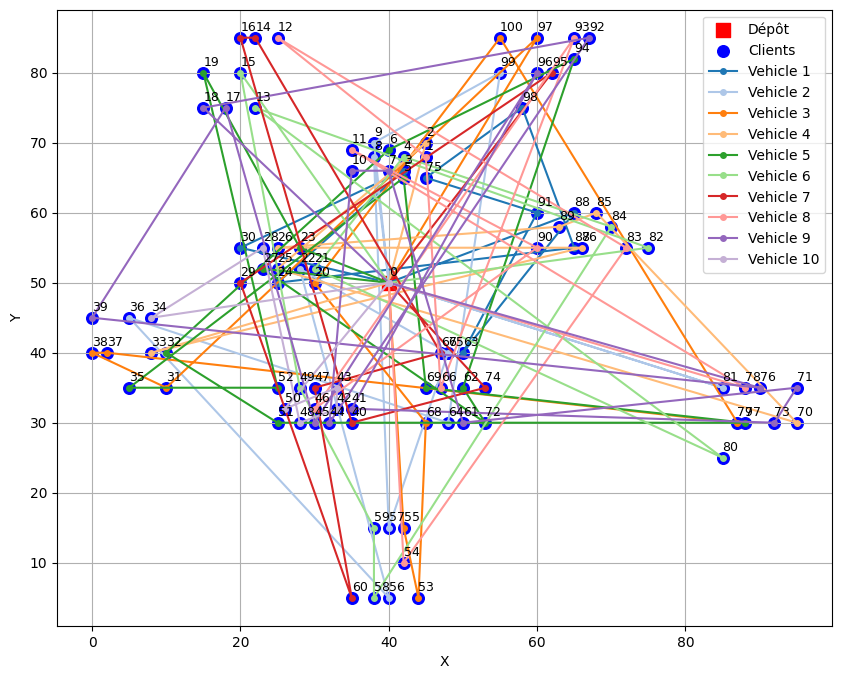

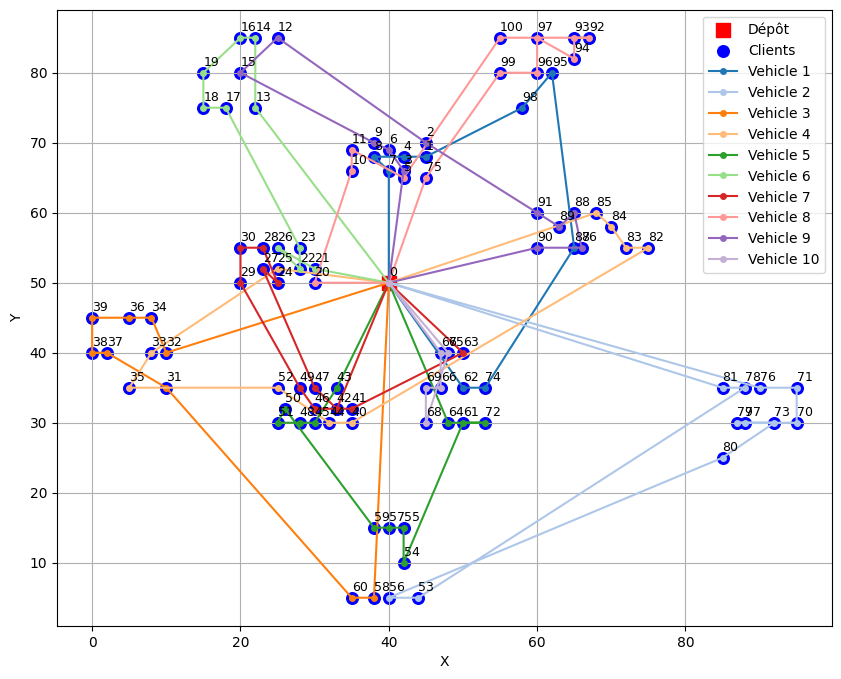

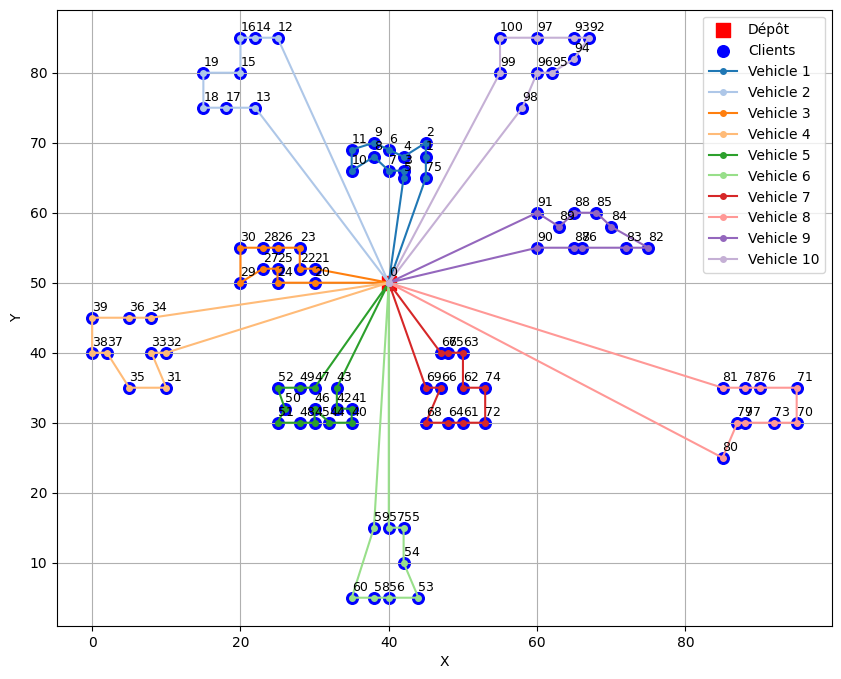

In [237]:
#test 
print(best_solution)
print(total_travel_distance(best_solution))

rand =random_solution()
print(rand)
print(total_travel_distance(rand))

best=tabu_search(rand,tabu_size,iter_max,nb_neighbors,nb_swaps_per_neighbor)
print(best)
print(total_travel_distance(best))

multi_val, multi_sol = multi_start(rand,tabu_size,iter_max,nb_neighbors,nb_swaps_per_neighbor,n_iter)
print(multi_sol)
print(multi_val)


neighbor = neighborhood(rand, 1, 3)
print(neighbor)
print(total_travel_distance(neighbor[0]))

show(rand, data_set)
show(best, data_set)
show(best_solution,data_set)
